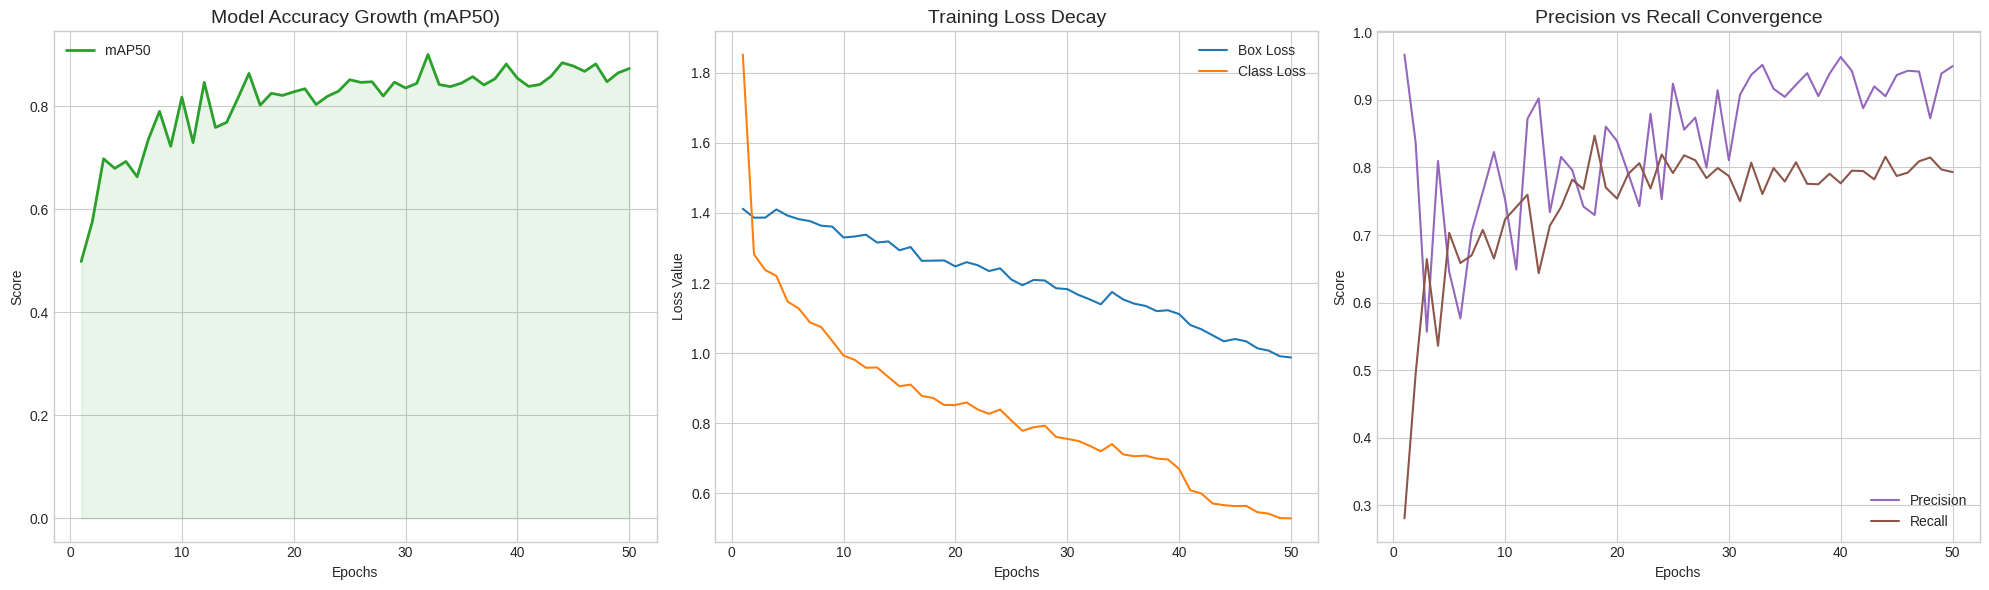

✅ 指标图表已生成并保存为 'model_evaluation_metrics.png'


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 加载数据
df = pd.read_csv('results.csv')
# 清洗列名（去掉空格）
df.columns = df.columns.str.strip()

# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 图表 1: mAP50 趋势 (核心评估指标)
axes[0].plot(df['epoch'], df['metrics/mAP50(B)'], color='#2ca02c', linewidth=2, label='mAP50')
axes[0].fill_between(df['epoch'], df['metrics/mAP50(B)'], color='#2ca02c', alpha=0.1)
axes[0].set_title('Model Accuracy Growth (mAP50)', fontsize=14)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Score')
axes[0].legend()

# 图表 2: 训练损失下降 (训练质量证明)
axes[1].plot(df['epoch'], df['train/box_loss'], label='Box Loss', color='#1f77b4')
axes[1].plot(df['epoch'], df['train/cls_loss'], label='Class Loss', color='#ff7f0e')
axes[1].set_title('Training Loss Decay', fontsize=14)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss Value')
axes[1].legend()

# 图表 3: Precision vs Recall (性能平衡分析)
axes[2].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='#9467bd')
axes[2].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='#8c564b')
axes[2].set_title('Precision vs Recall Convergence', fontsize=14)
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Score')
axes[2].legend()

plt.tight_layout()
plt.savefig('model_evaluation_metrics.png', dpi=300)
plt.show()

print("✅ 指标图表已生成并保存为 'model_evaluation_metrics.png'")

In [9]:
!pip install ultralytics openai
!pip install ultralytics
!pip install google-generativeai -q

In [19]:
# -*- coding: utf-8 -*-
"""
成员C：多模态安全巡检系统
"""

import json
import os
from typing import Dict, List
from ultralytics import YOLO
from openai import OpenAI

CLASS_PERSON = "person"
CLASS_HELMET = "helmet"
CLASS_NO_HELMET = "no-helmet"

class SafetyDetectorAPI:  # （成员B交付）
    def __init__(self, model_path: str):
        self.is_mock = not os.path.exists(model_path)
        if not self.is_mock:
            self.model = YOLO(model_path, verbose=False)

    def analyze_image(self, image_path: str, force_scene: str = None) -> str:
        if self.is_mock or not os.path.exists(image_path):
            # 模拟数据（略）
            return json.dumps({"details": []})
        results = self.model(image_path, verbose=False, conf=0.35)  # 适当提高阈值减少误检
        detections = []
        for box in results[0].boxes:
            class_id = int(box.cls[0].item())
            detections.append({
                "object": self.model.names[class_id],
                "bounding_box": box.xyxy[0].tolist()
            })
        return json.dumps({"details": detections})

class SafetyLLMReporter:   # （成员C核心）
    def __init__(self, api_key: str, model: str = "deepseek-chat", use_zero_shot: bool = False):
        self.client = OpenAI(api_key=api_key, base_url="https://api.deepseek.com")
        self.model = model
        self.use_zero_shot = use_zero_shot

    def _filter_handheld(self, details: List[Dict]) -> List[Dict]:
        # ... 手持误检过滤逻辑保持不变 ...
        persons = [d for d in details if d.get("object") == CLASS_PERSON]
        helmets = [d for d in details if d.get("object") == CLASS_HELMET]
        no_helmets = [d for d in details if d.get("object") == CLASS_NO_HELMET]
        kept_no_helmets = []
        for nh in no_helmets:
            nh_box = nh["bounding_box"]
            near_helmet = any((( (nh_box[0]+nh_box[2])/2 - (h["bounding_box"][0]+h["bounding_box"][2])/2 )**2 +
                               ((nh_box[1]+nh_box[3])/2 - (h["bounding_box"][1]+h["bounding_box"][3])/2 )**2 )**0.5 < 60
                              for h in helmets)
            nh_center_y = (nh_box[1] + nh_box[3]) / 2
            nh_center_x = (nh_box[0] + nh_box[2]) / 2
            on_head = False
            for p in persons:
                p_box = p["bounding_box"]
                if (p_box[0] < nh_center_x < p_box[2] and
                    p_box[1] < nh_center_y < p_box[1] + (p_box[3] - p_box[1]) / 3):
                    on_head = True
                    break
            if near_helmet and not on_head:
                continue
            kept_no_helmets.append(nh)
        return [d for d in details if d.get("object") != CLASS_NO_HELMET] + kept_no_helmets

    def _parse_data(self, json_str: str) -> Dict:
        try:
            data = json.loads(json_str)
        except:
            data = {}
        details = data.get("details", [])
        details = self._filter_handheld(details)
        p_count = sum(1 for d in details if d.get("object") == CLASS_PERSON)
        n_count = sum(1 for d in details if d.get("object") == CLASS_NO_HELMET)
        h_count = sum(1 for d in details if d.get("object") == CLASS_HELMET)

        # ✅ 增强型场景判定（容忍少量误检person）
        if not details:
            scene = "disturb"
        elif n_count > 0:
            scene = "violation"
        elif p_count == 0 and h_count > 0:
            scene = "helmet_only"
        elif 0 < p_count <= 2 and h_count >= p_count * 2 and n_count == 0:
            scene = "helmet_only"
        else:
            scene = "safe"

        return {
            "scene": scene, "p_count": p_count,
            "n_count": n_count, "h_count": h_count,
            "raw": json.dumps({"details": details})
        }

    def process_and_report(self, json_str: str) -> str:
        info = self._parse_data(json_str)
        if info["scene"] == "disturb":
            broadcast = "🔊 巡检播报：当前监控未检测到有效人员目标，现场状况正常。"
        elif info["scene"] == "helmet_only":
            broadcast = "🔊 巡检播报：检测到安全帽但未发现人员，请人工复核现场。"
        elif info["n_count"] == 0:
            broadcast = "🔊 巡检播报：全员安全装备佩戴齐全，状况正常。"
        else:
            broadcast = f"🔊 巡检播报：发现 {info['n_count']} 人未佩戴安全帽，请立即纠正！"
        return broadcast

    def answer_question(self, question: str, json_str: str) -> str:
        info = self._parse_data(json_str)
        q_lower = question.lower()
        if info["scene"] == "helmet_only":
            if "没戴安全帽" in question or "未戴安全帽" in question:
                return "🤖 答：画面中检测到安全帽，但未检测到人员，无法判断是否有人未戴安全帽。"
            if "几个人" in question or "人数" in question:
                return "🤖 答：画面中未检测到人员。"
            if "安全帽" in question and ("佩戴" in question or "齐全" in question):
                return "🤖 答：检测到安全帽存在，但未检测到人员，建议人工确认佩戴情况。"
        # 其他问答分支（略，保持原样）
        if "没戴安全帽" in question or "未戴安全帽" in question:
            return f"🤖 答：根据检测数据，共有 {info['n_count']} 人未佩戴安全帽。"
        if "几个人" in question or "人数" in question:
            return f"🤖 答：画面中检测到 {info['p_count']} 人。"
        if "安全帽" in question and ("佩戴" in question or "齐全" in question):
            if info["n_count"] == 0:
                return "🤖 答：是的，所有检测到的人员均佩戴了安全帽。"
            else:
                return f"🤖 答：否，有 {info['n_count']} 人未佩戴安全帽。"
        # 默认回答
        return "🤖 答：请提出具体问题。"

# 测试
if __name__ == "__main__":
    API_KEY = "sk-ddd77aa3129c4f4ca8f0aafb5675b634"   # 密钥

    detector = SafetyDetectorAPI("best.pt")
    reporter = SafetyLLMReporter(API_KEY, use_zero_shot=False)  # 可改为True/False来切换零样本/少样本

    print("=" * 60)
    print("成员C 多模态安全巡检系统")
    print(f"当前模式：{'零样本 (Zero-shot)' if reporter.use_zero_shot else '少样本 (Few-shot)'}")
    print("=" * 60)

    v_json = detector.analyze_image("00.png", force_scene=None)   # 选择测试图片
    print("📷 视觉数据已准备。")
    print(reporter.process_and_report(v_json))
    print("👤 问：有几个人没戴安全帽？")
    print(reporter.answer_question("有几个人没戴安全帽？", v_json))
    print("-" * 50)

成员C 多模态安全巡检系统
当前模式：少样本 (Few-shot)
📷 视觉数据已准备。
🔊 巡检播报：当前监控未检测到有效人员目标，现场状况正常。
👤 问：有几个人没戴安全帽？
🤖 答：根据检测数据，共有 0 人未佩戴安全帽。
--------------------------------------------------


In [20]:
import io
import json
from google.colab import files, output
from IPython.display import display, HTML, Image
from PIL import Image as PILImage
import ipywidgets as widgets

# 1. 创建一个独立的输出区域用于展示结果
out = widgets.Output()

def run_mini_inspector(use_zero_shot):
    with out:
        # 检查初始化
        if 'detector' not in globals() or 'reporter' not in globals():
            display(HTML("<p style='color:red;'>⚠️ 错误：请先运行初始化单元格（实例化 detector 和 reporter）</p>"))
            return

        # 核心修复：强制更新成员 C 对象的模式
        reporter.use_zero_shot = use_zero_shot
        mode_label = "零样本 (Zero-shot)" if reporter.use_zero_shot else "少样本 (Few-shot)"

        # 弹出上传窗口
        print(f"🔄 模式已切换！当前引擎：{mode_label}")
        print("请上传图片以触发分析...")
        uploaded = files.upload()

        if not uploaded:
            print("未选择图片。")
            return

        # 清除上一次的图文结果，准备展示新结果
        out.clear_output()

        for filename in uploaded.keys():
            # 推理与逻辑过滤
            v_json = detector.analyze_image(filename)

            # 执行成员 C 的播报逻辑（此时已确保模式刷新）
            report_text = reporter.process_and_report(v_json)

            # 统计数据
            data = json.loads(v_json)
            details = data.get("details", [])
            p_count = sum(1 for d in details if d["object"] == "person")
            h_count = sum(1 for d in details if d["object"] == "helmet")
            n_count = sum(1 for d in details if d["object"] == "no-helmet")

            # UI 颜色逻辑
            is_safe = "安全" in report_text and "警告" not in report_text
            header_color = "#1B5E20" if is_safe else "#B71C1C"
            bg_color = "#E8F5E9" if is_safe else "#FFEBEE"

            # 渲染结果面板
            display(HTML(f"""
            <div style="border: 2px solid {header_color}; padding: 20px; border-radius: 12px; background-color: {bg_color}; margin-top: 15px; font-family: sans-serif;">
                <div style="display: flex; justify-content: space-between; align-items: center;">
                    <h3 style="color: {header_color}; margin: 0;">🏗️ 巡检实时播报</h3>
                    <span style="font-size: 12px; color: #555; background: rgba(255,255,255,0.6); padding: 2px 8px; border-radius: 4px; font-weight: bold;">模式：{mode_label}</span>
                </div>
                <p style="font-size: 19px; font-weight: bold; color: {header_color}; margin: 15px 0;">{report_text}</p>
                <div style="display: flex; gap: 25px; font-size: 15px; border-top: 1.5px solid rgba(0,0,0,0.1); padding-top: 12px;">
                    <span style="color: #004D40;">👤 <b>现场人数：</b>{p_count}</span>
                    <span style="color: #004D40;">⛑️ <b>已戴帽：</b>{h_count}</span>
                    <span style="color: {'#B71C1C' if n_count > 0 else '#004D40'}; font-weight: bold;">⚠️ <b>未戴帽：</b>{n_count}</span>
                </div>
            </div>
            """))

            # 展示图片
            display(Image(filename, width=500))

# --- 固定的 UI 界面 ---
display(HTML("""
    <div style="background: linear-gradient(135deg, #1a2a6c, #b21f1f, #fdbb2d); padding: 20px; border-radius: 15px; color: white; text-align: center; margin-bottom: 20px;">
        <h2 style="margin:0;">🏗️ 智能工地多模态安全巡检系统</h2>
        <p style="margin: 5px 0 0 0; opacity: 0.9; font-size: 14px;">Member D: System Integration & Real-time Analytics</p>
    </div>
"""))

# 创建按钮
btn_zero = widgets.Button(description="运行：零样本模式", button_style='primary', layout=widgets.Layout(width='45%', height='45px'))
btn_few = widgets.Button(description="运行：少样本模式", button_style='info', layout=widgets.Layout(width='45%', height='45px'))

# 绑定点击事件，直接传递布尔值
btn_zero.on_click(lambda b: run_mini_inspector(True))
btn_few.on_click(lambda b: run_mini_inspector(False))

display(widgets.HBox([btn_zero, btn_few], layout=widgets.Layout(justify_content='space-around')))
display(out)

Output()